<a href="https://colab.research.google.com/github/guillemostafa/data/blob/main/Final_DS3_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINAL

In [3]:
# Instalación
!pip install gdown
!pip install -q spacy scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
# Imports
import pandas as pd
import numpy as np
import re
import gdown
import spacy
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

np.random.seed(42)
nlp = spacy.load("en_core_web_sm")

In [5]:
books_rating_id = "1sd_QeCs5l1QmI996H4Cut1X0hLMBXOrs"
books_data_id = "1bLaXNyJWuVrJZviWvWYj3F7ngPfWJIGs"

# Descargar los archivos
gdown.download(f'https://drive.google.com/uc?id={books_rating_id}', 'Books_rating.csv', quiet=False)
gdown.download(f'https://drive.google.com/uc?id={books_data_id}', 'books_data.csv', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1sd_QeCs5l1QmI996H4Cut1X0hLMBXOrs
From (redirected): https://drive.google.com/uc?id=1sd_QeCs5l1QmI996H4Cut1X0hLMBXOrs&confirm=t&uuid=46b92f63-457d-4c86-b79d-de496d126948
To: /content/Books_rating.csv
100%|██████████| 2.86G/2.86G [00:30<00:00, 95.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bLaXNyJWuVrJZviWvWYj3F7ngPfWJIGs
From (redirected): https://drive.google.com/uc?id=1bLaXNyJWuVrJZviWvWYj3F7ngPfWJIGs&confirm=t&uuid=e1d73e57-eabb-44bf-b08d-9d22d24f987a
To: /content/books_data.csv
100%|██████████| 181M/181M [00:01<00:00, 97.2MB/s]


'books_data.csv'

In [6]:
df_reviews = pd.read_csv('Books_rating.csv')
# Convertir timestamp a fecha
df_reviews['review/time'] = pd.to_datetime(df_reviews['review/time'], unit='s', errors='coerce')
df_reviews['review/time'] = df_reviews['review/time'].dt.strftime('%d/%m/%Y')

df_reviews.head(5)
# Vista inicial
print("df_reviews tiene {0} registros y {1} columnas.".format(df_reviews.shape[0], df_reviews.shape[1]))

df_reviews tiene 3000000 registros y 10 columnas.


In [7]:
# Separar helpfulness en votos útiles y totales
df_reviews[['helpful_votes', 'total_votes']] = df_reviews['review/helpfulness'].str.split('/', expand=True).astype(float)
# Calcula proporción de votos útiles
df_reviews['helpfulness_ratio'] = df_reviews['helpful_votes'] / df_reviews['total_votes']
df_reviews.head(5)

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text,helpful_votes,total_votes,helpfulness_ratio
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,23/10/1999,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...,7.0,7.0,1.000000
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,21/09/2004,Really Enjoyed It,I don't care much for Dr. Seuss but after read...,10.0,10.0,1.000000
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,09/03/2004,Essential for every personal and Public Library,"If people become the books they read and if ""t...",10.0,11.0,0.909091
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,25/07/2004,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D...",7.0,7.0,1.000000
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,10/02/2005,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...,3.0,3.0,1.000000


In [8]:
df_books = pd.read_csv('books_data.csv')

In [9]:
#print("df_books tiene {0} registros y {1} columnas.".format(df_books.shape[0], df_books.shape[1]))

In [10]:
print("Dataset de Libros (cabecera):")
display(df_books.head())

Dataset de Libros (cabecera):


,Title,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
0,Its Only Art If Its Well Hung!,NaN,['Julie Strain'],http://books.google.com/books/content?id=DykPA...,http://books.google.nl/books?id=DykPAAAACAAJ&d...,NaN,1996,http://books.google.nl/books?id=DykPAAAACAAJ&d...,['Comics & Graphic Novels'],NaN
1,Dr. Seuss: American Icon,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
2,Wonderful Worship in Smaller Churches,This resource includes twelve principles in un...,['David R. Ray'],http://books.google.com/books/content?id=2tsDA...,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,NaN,2000,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,['Religion'],NaN
3,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,['Veronica Haddon'],http://books.google.com/books/content?id=aRSIg...,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,iUniverse,2005-02,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,['Fiction'],NaN
4,"Nation Dance: Religion, Identity and Cultural ...",NaN,['Edward Long'],NaN,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,2003-03-01,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,NaN


In [11]:
duplicados_titulo = df_books[df_books.duplicated(subset='Title', keep=False)]
print(f"Registros con títulos duplicados: {len(duplicados_titulo)}")
print(f"Títulos únicos con duplicados: {duplicados_titulo['Title'].nunique()}")

Registros con títulos duplicados: 0
Títulos únicos con duplicados: 0


In [12]:
# Normalizar títulos (evita problemas de espacios o mayúsculas)
df_books['Title'] = df_books['Title'].str.strip().str.lower()
df_reviews['Title'] = df_reviews['Title'].str.strip().str.lower()

In [13]:
#uno lo dos df por titulo
df_merged = pd.merge(df_reviews, df_books, on='Title', how='left')
df_merged.head(5)


,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text,...,helpfulness_ratio,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
0,1882931173,its only art if its well hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,23/10/1999,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...,...,1.000000,NaN,['Julie Strain'],http://books.google.com/books/content?id=DykPA...,http://books.google.nl/books?id=DykPAAAACAAJ&d...,NaN,1996,http://books.google.nl/books?id=DykPAAAACAAJ&d...,['Comics & Graphic Novels'],NaN
1,0826414346,dr. seuss: american icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,21/09/2004,Really Enjoyed It,I don't care much for Dr. Seuss but after read...,...,1.000000,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
2,0826414346,dr. seuss: american icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,09/03/2004,Essential for every personal and Public Library,"If people become the books they read and if ""t...",...,0.909091,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
3,0826414346,dr. seuss: american icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,25/07/2004,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D...",...,1.000000,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
4,0826414346,dr. seuss: american icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,10/02/2005,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...,...,1.000000,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN


In [14]:
#Ya tengo todo unificado borro los demas df
del df_books, df_reviews
import gc
gc.collect()

110

In [15]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'<.*?>', ' ', text)        # HTML
    text = re.sub(r'http\S+', ' ', text)      # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)     # símbolos
    text = re.sub(r'\s+', ' ', text)          # espacios extra

    return text.strip()

In [16]:
df = df_merged.sample(200000, random_state=42)
df = df[['review/text','review/score']]
df = df.dropna(subset=['review/text'])

df['clean_text'] = df['review/text'].map(clean_text)

In [57]:
import pandas as pd
import re
from nltk.corpus import stopwords
import nltk

# Descargar stopwords en inglés si no lo has hecho
nltk.download('stopwords')

def clean_text(text):
    text = text.lower()  # pasar a minúsculas
    text = re.sub(r'[^a-z\s]', '', text)  # eliminar caracteres que no sean letras ni espacios
    text = re.sub(r'\s+', ' ', text).strip()  # eliminar espacios extra
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words]  # eliminar stopwords en inglés
    return " ".join(words)

# Aplicar limpieza a la columna 'text' y guardar en 'clean_text'
df['clean_text'] = df['review/text'].map(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
df.head(10)

,review/text,review/score,clean_text,sentiment,review_length
174188,This classic is witty and thought provoking. T...,5.0,classic witty thought provoking plot twisty en...,1,158
910660,Denise sure knows how to write a terrific roma...,5.0,denise sure knows write terrific romantic susp...,1,249
2012875,"This book was just as I expected it to be, ful...",4.0,book expected full quirky characters healthy d...,1,353
2972237,John Steinbeck's Travels with Charley earns a ...,4.0,john steinbecks travels charley earns rank sev...,1,2572
3259700,Going on an adventure with a Hobbit is such a ...,5.0,going adventure hobbit lesson kinds creatures ...,1,135
2258900,Personal stories and opinions about her own do...,1.0,personal stories opinions dogs problem solving...,0,155
2608694,"Last winter, I rented Cranford, the BBC minise...",5.0,last winter rented cranford bbc miniseries sta...,1,1306
94603,I really liked this book. If anyone is sick an...,5.0,really liked book anyone sick tired endless ja...,1,200
1286092,"Would you give up color, uniqueness, and choic...",5.0,would give color uniqueness choice live commun...,1,1043
1686674,Kinsey tags her umpteenth cold case when an ol...,4.0,kinsey tags umpteenth cold case old friend ask...,1,2162


In [17]:

from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=20,
    max_df=0.7,
    stop_words="english"
)
X = tfidf.fit_transform(df['clean_text'])

In [19]:
df['sentiment'] = df['review/score'].apply(
    lambda x: 1 if x >= 4 else 0
)

y = df['sentiment']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
df['clean_text'] = df['clean_text'].astype(str)

In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test,y_pred))

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.8779

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.54      0.64      8025
           1       0.89      0.96      0.93     31975

    accuracy                           0.88     40000
   macro avg       0.84      0.75      0.78     40000
weighted avg       0.87      0.88      0.87     40000


Confusion Matrix

[[ 4322  3703]
 [ 1181 30794]]


Debido al gran tamaño del dataset (3 millones de registros), se utilizó una estrategia de muestreo para optimizar el uso de memoria y tiempo de entrenamiento. Posteriormente, el texto fue limpiado mediante expresiones regulares y transformado utilizando TF-IDF con n-gramas. Finalmente, se entrenó un modelo de Logistic Regression para la clasificación de sentimientos.

# ***FINAL***

In [26]:
!pip install wordcloud --quiet

In [27]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from wordcloud import WordCloud

In [28]:
df = df_merged.copy()

In [29]:
df = df.sample(200000, random_state=42)

In [30]:
df = df[['review/text','review/score']]

In [31]:
df = df.dropna(subset=['review/text'])

In [32]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [33]:
df["clean_text"] = df["review/text"].map(clean_text)

In [34]:
df["sentiment"] = df["review/score"].apply(
    lambda x: 1 if x >= 4 else 0
)

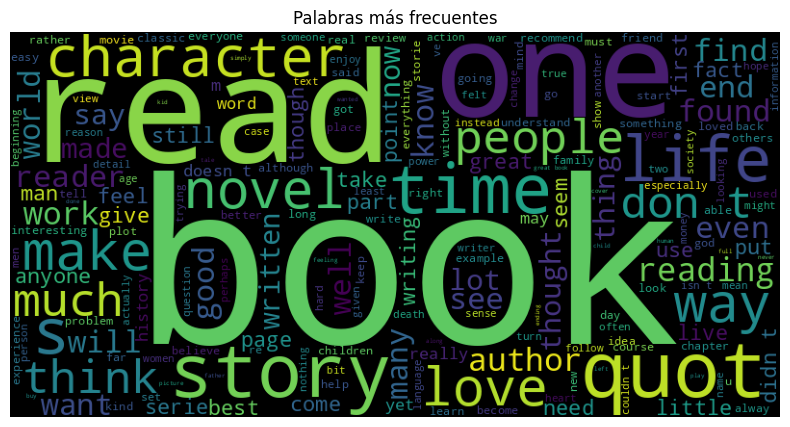

In [35]:
text = " ".join(df["clean_text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Palabras más frecuentes")
plt.show()

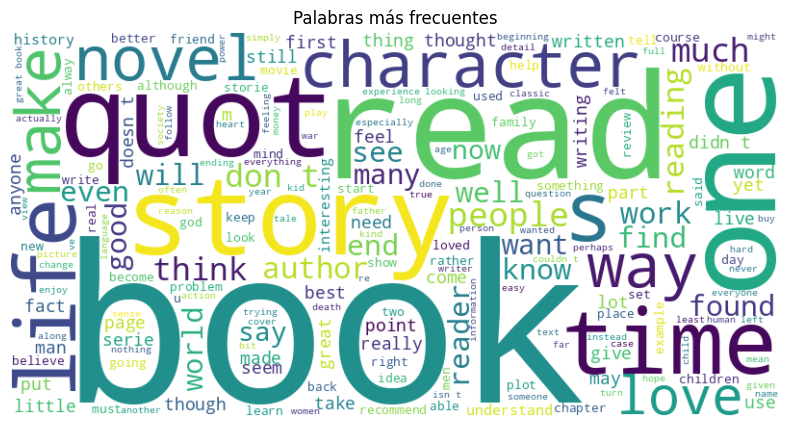

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todos los textos limpios en una sola cadena
text = " ".join(df["clean_text"])

# Crear la nube de palabras con parámetros ajustables
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Mostrar la nube de palabras
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Palabras más frecuentes")
plt.show()


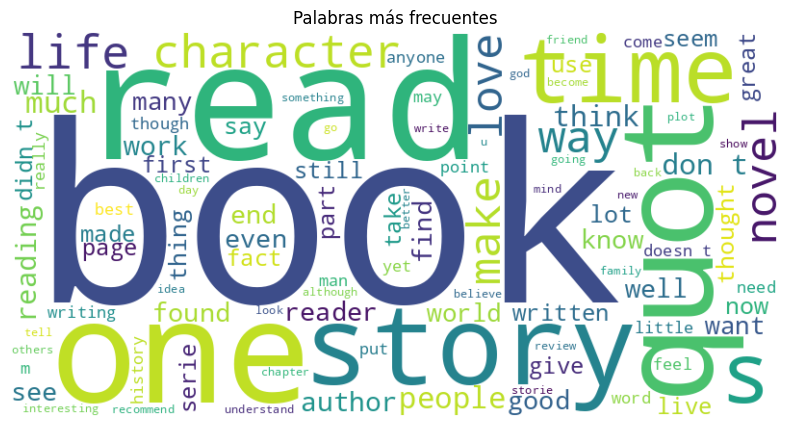

Triada (3 palabras más frecuentes):
the: 1653066
and: 901584
of: 857037


In [54]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

# Texto unido
text = " ".join(df["clean_text"])

# Definir stopwords adicionales si quieres excluir más palabras comunes
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["palabra1", "palabra2"])  # agrega palabras que quieras excluir

# Crear nube de palabras con stopwords y fondo blanco
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100
).generate(text)

# Mostrar nube de palabras
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Palabras más frecuentes")
plt.show()

# Obtener las 3 palabras más frecuentes (triada)
word_counts = Counter(text.split())
triada = word_counts.most_common(3)
print("Triada (3 palabras más frecuentes):")
for word, count in triada:
    print(f"{word}: {count}")


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.2,
    random_state=42
)

In [37]:
pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        min_df=15,
        max_df=0.75,
        stop_words="english",
        ngram_range=(1,2)
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [38]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.75, max_features=5000, min_df=15,
                                 ngram_range=(1, 2), stop_words='english')),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8779

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.54      0.64      8025
           1       0.89      0.96      0.93     31975

    accuracy                           0.88     40000
   macro avg       0.84      0.75      0.78     40000
weighted avg       0.87      0.88      0.87     40000


Confusion Matrix

[[ 4322  3703]
 [ 1181 30794]]


In [40]:
probs = pipeline_lr.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.8928611907180211


In [41]:
pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1,2)
    )),
    ("model", LinearSVC())
])

pipeline_svm.fit(X_train, y_train)

y_pred_svm = pipeline_svm.predict(X_test)

print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))

Accuracy SVM: 0.87455


In [42]:
tfidf = pipeline_lr.named_steps["tfidf"]
model = pipeline_lr.named_steps["model"]

feature_names = tfidf.get_feature_names_out()

coef = model.coef_[0]

top_pos = coef.argsort()[-10:]
top_neg = coef.argsort()[:10]

print("Palabras positivas:")
print([feature_names[i] for i in top_pos])

print("\nPalabras negativas:")
print([feature_names[i] for i in top_neg])

Palabras positivas:
['finest', 'highly', 'superb', 'delightful', 'awesome', 'great', 'amazing', 'wonderful', 'excellent', 'highly recommend']

Palabras negativas:
['disappointing', 'unfortunately', 'worst', 'boring', 'disappointment', 'poorly', 'lacks', 'disappointed', 'tedious', 'waste']


In [43]:
results = pd.DataFrame({
    "text": X_test,
    "real": y_test,
    "pred": y_pred
})

errors = results[results["real"] != results["pred"]]

errors.head(10)

,text,real,pred
479748,i have long known that circumcision is a highl...,1,0
2917577,while i understand that this book was written ...,0,1
2599989,i really wanted to like this book interesting ...,0,1
1051134,dead skip is the first book about the daniel k...,1,0
1334671,the story itself was really cool i loved the i...,0,1
2551525,this is just another tale pumped out by tsr to...,0,1
377283,as i write this some reviewers have preceded m...,1,0
2801255,with all the talk about the da vinci code i de...,0,1
956925,i have read all of barbara pym s published wor...,0,1
2282383,letters formed words flowed as emily bront mov...,0,1


In [49]:
total_errors = len(errors)
error_rate = total_errors / len(results)
print(f"Errores totales: {total_errors}")
print(f"Tasa de error: {error_rate:.2%}")


Errores totales: 4884
Tasa de error: 12.21%


In [50]:
print(errors[["text", "real", "pred"]].head(10))


                                                      text  real  pred
479748   i have long known that circumcision is a highl...     1     0
2917577  while i understand that this book was written ...     0     1
2599989  i really wanted to like this book interesting ...     0     1
1051134  dead skip is the first book about the daniel k...     1     0
1334671  the story itself was really cool i loved the i...     0     1
2551525  this is just another tale pumped out by tsr to...     0     1
377283   as i write this some reviewers have preceded m...     1     0
2801255  with all the talk about the da vinci code i de...     0     1
956925   i have read all of barbara pym s published wor...     0     1
2282383  letters formed words flowed as emily bront mov...     0     1


In [51]:
print(errors["real"].value_counts())
print(errors["pred"].value_counts())


real
0    3703
1    1181
Name: count, dtype: int64
pred
1    3703
0    1181
Name: count, dtype: int64


Errores totales: 4884
Tasa de error: 12.21%
                                                      text  real  pred
479748   i have long known that circumcision is a highl...     1     0
2917577  while i understand that this book was written ...     0     1
2599989  i really wanted to like this book interesting ...     0     1
1051134  dead skip is the first book about the daniel k...     1     0
1334671  the story itself was really cool i loved the i...     0     1
2551525  this is just another tale pumped out by tsr to...     0     1
377283   as i write this some reviewers have preceded m...     1     0
2801255  with all the talk about the da vinci code i de...     0     1
956925   i have read all of barbara pym s published wor...     0     1
2282383  letters formed words flowed as emily bront mov...     0     1
real
0    3703
1    1181
Name: count, dtype: int64


/tmp/ipykernel_55167/3108783980.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.index, y=error_counts.values, palette="viridis")


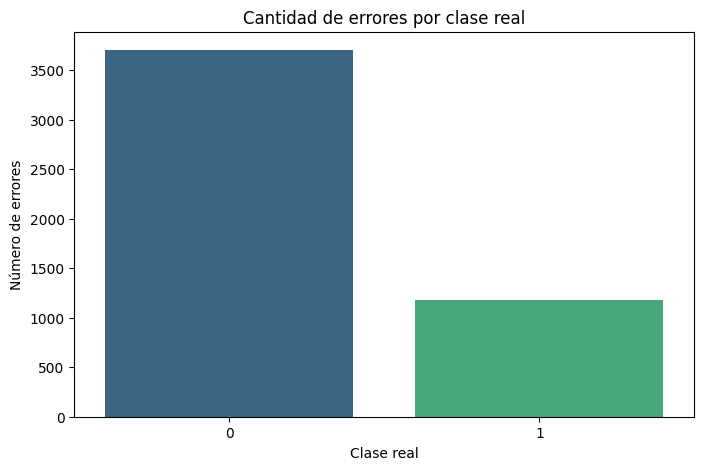

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear DataFrame con resultados
results = pd.DataFrame({
    "text": X_test,
    "real": y_test,
    "pred": y_pred
})

# Filtrar errores
errors = results[results["real"] != results["pred"]]

# Estadísticas básicas
total_errors = len(errors)
error_rate = total_errors / len(results)
print(f"Errores totales: {total_errors}")
print(f"Tasa de error: {error_rate:.2%}")

# Mostrar primeros 10 errores con contexto
print(errors[["text", "real", "pred"]].head(10))

# Conteo de errores por clase real
error_counts = errors["real"].value_counts()
print(error_counts)

# Visualización: errores por clase real
plt.figure(figsize=(8,5))
sns.barplot(x=error_counts.index, y=error_counts.values, palette="viridis")
plt.title("Cantidad de errores por clase real")
plt.xlabel("Clase real")
plt.ylabel("Número de errores")
plt.show()


La gráfica de errores por clase real te muestra cuántos ejemplos de cada clase el modelo clasificó incorrectamente.

Cómo interpretarla:
Barras altas: Indican que el modelo tiene más dificultades para predecir correctamente esa clase.
Barras bajas o cero: Significan que el modelo clasifica bien esa clase.
Qué hacer según la gráfica:
Si una clase tiene muchos errores, revisa:

¿Hay pocos ejemplos de esa clase en el entrenamiento? Podrías necesitar más datos.
¿Esa clase es muy parecida a otras? Quizás el modelo confunde clases similares.
¿El texto de esa clase es más complejo o ambiguo? Podrías mejorar el preprocesamiento o usar modelos más potentes.
Para clases con pocos errores, el modelo ya funciona bien, pero siempre es bueno validar con más datos.

En resumen, la gráfica te guía a enfocar esfuerzos de mejora donde el modelo falla más.

In [45]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from wordcloud import WordCloud

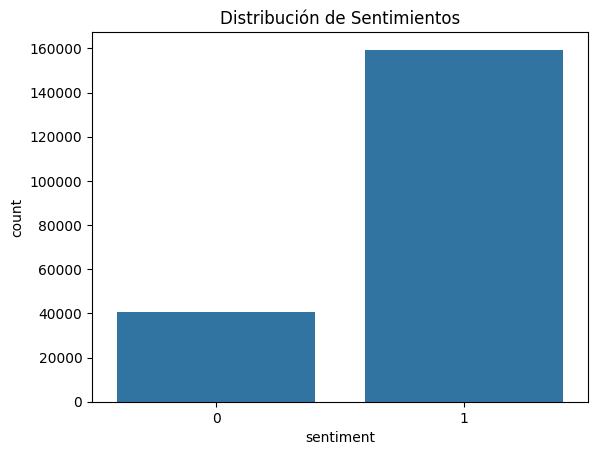

In [46]:
sns.countplot(x=df["sentiment"])
plt.title("Distribución de Sentimientos")
plt.show()

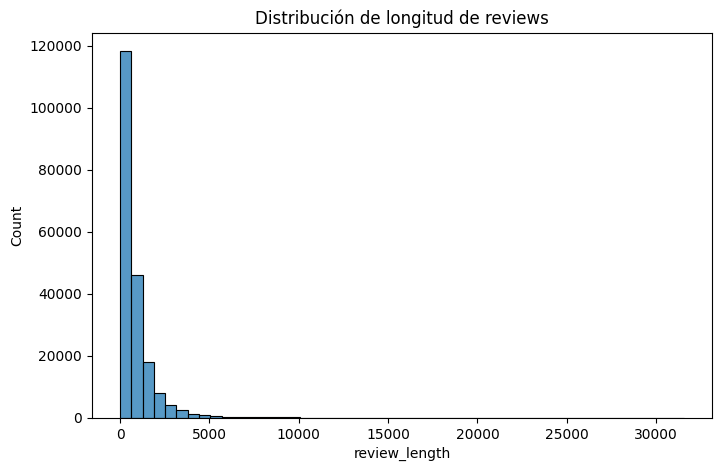

In [47]:
df["review_length"] = df["clean_text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["review_length"], bins=50)
plt.title("Distribución de longitud de reviews")
plt.show()

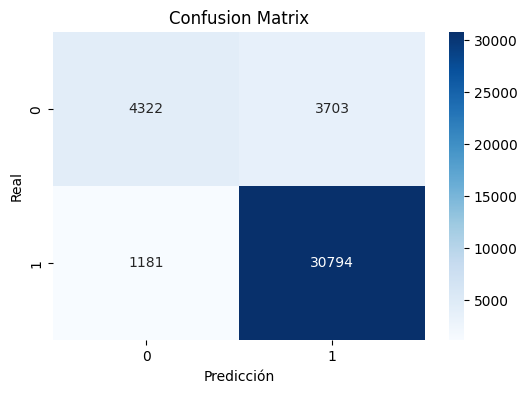

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Confusion Matrix")

plt.show()